<div style="display:grid; grid-template-columns:repeat(auto-fit,minmax(190px,1fr)); gap:12px; margin:18px 0 8px;">
  <div style="border:1px solid #e5e7eb; border-radius:10px; padding:14px; background:#ffffff;"><strong>1. Deconvolution</strong><br><span style="color:#586069;">Build spot-level type supervision.</span></div>
  <div style="border:1px solid #e5e7eb; border-radius:10px; padding:14px; background:#ffffff;"><strong>2. Grid embedding</strong><br><span style="color:#586069;">Extract dense H&E features.</span></div>
  <div style="border:1px solid #e5e7eb; border-radius:10px; padding:14px; background:#ffffff;"><strong>3. Train</strong><br><span style="color:#586069;">Fit gene and type heads.</span></div>
  <div style="border:1px solid #e5e7eb; border-radius:10px; padding:14px; background:#ffffff;"><strong>4. Aggregate</strong><br><span style="color:#586069;">Map grids to polygons/cells.</span></div>
  <div style="border:1px solid #e5e7eb; border-radius:10px; padding:14px; background:#ffffff;"><strong>5. Evaluation</strong><br><span style="color:#586069;">Compare type and expression maps.</span></div>
</div>

## Run Checklist

| Item | Setting |
| --- | --- |
| Project root | `SpaceRec/` |
| Notebook path | `spacerec/notebooks/run_spacerec.ipynb` |
| Required local artifacts | `data/` and `results/` at the repository root |
| Preferred environment | `conda activate spacerec` on an allocated GPU compute node |
| Main outputs | `results/<dataset>/<step>/` |

> For smoke tests, set small values for `max_patches`, `limit_spots`, and `max_epochs` before running the expensive cells.

## Workflow Map

`Visium + scRNA reference` -> `deconv.csv` -> `grid_embedding.h5` -> `grid_predictions.h5` -> `spacerec_ct.csv` / figures


In [ ]:
from __future__ import annotations

import base64
import json
import sys
from pathlib import Path
from pprint import pprint

import pandas as pd
from IPython.display import HTML
from IPython.display import display

def find_spacerec_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "spacerec" / "api.py").is_file():
            return path
    raise FileNotFoundError("Could not find project root containing spacerec/api.py")


SPACEREC_ROOT = find_spacerec_root()
if str(SPACEREC_ROOT) not in sys.path:
    sys.path.insert(0, str(SPACEREC_ROOT))

import spacerec.api as spacerec


dataset = "brca"  # "brca" or "crc"
sample_id = "BREAST"  # e.g. "BREAST" or "COLON_P2"

pwd = SPACEREC_ROOT
output_root = pwd / "results" / dataset

deconv_dir = output_root / "deconv"
grid_dir = output_root / "grid_embedding"
train_dir = output_root / "train"
aggregate_dir = output_root / "aggregate"
evaluation_dir = output_root / "Evaluation"


def display_summary_table(summary: dict, rows: list[tuple[str, object]]) -> None:
    table = pd.DataFrame(rows, columns=["Field", "Value"])
    display(table.style.hide(axis="index").set_properties(**{"text-align": "left"}))


def display_image_pair(left_png: str | Path, right_png: str | Path) -> None:
    def image_tag(path: str | Path) -> str:
        encoded = base64.b64encode(Path(path).read_bytes()).decode("ascii")
        return f'<img src="data:image/png;base64,{encoded}" style="width:49%; height:auto; object-fit:contain;">'

    display(HTML(
        '<div style="display:flex; gap:12px; align-items:flex-start; width:100%;">'
        + image_tag(left_png)
        + image_tag(right_png)
        + '</div>'
    ))


def display_ge_summary(summary: dict) -> None:
    patch_summary = summary.get("patch_summary", {})
    gpu_selection = summary.get("gpu_selection", {})
    bbox = patch_summary.get("fullres_bbox", {})
    rows = [
        ("Output H5", summary.get("output_h5")),
        ("Summary JSON", summary.get("summary_json")),
        ("Feature Key", summary.get("feature_key")),
        ("Feature Dim", summary.get("feature_dim")),
        ("Export Patches", summary.get("n_export_patches")),
        ("Dense Grids", summary.get("n_grids")),
        ("Supervised Grids", summary.get("n_supervised_grids")),
        ("Image Size", patch_summary.get("image_size")),
        ("Thumbnail Size", patch_summary.get("thumbnail_size")),
        ("Fullres BBox", bbox),
        ("Selected GPU", gpu_selection.get("physical_index")),
        ("GPU Free MB", gpu_selection.get("memory_free_mb")),
        ("Complete", summary.get("complete")),
        ("Elapsed Seconds", round(float(summary.get("elapsed_seconds", 0.0)), 2)),
    ]
    display_summary_table(summary, rows)


def display_train_summary(summary: dict) -> None:
    run_dir = Path(summary.get("run_dir", train_dir))
    metadata_path = run_dir / "metadata.json"
    metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
    model_summary = metadata.get("model_summary", metadata)
    gpu_selection = summary.get("gpu_selection") or metadata.get("gpu_selection") or {}
    model_rows = [
        ("Run Dir", summary.get("run_dir")),
        ("Architecture", model_summary.get("architecture")),
        ("Head Mode", model_summary.get("head_mode")),
        ("Set Transformer", model_summary.get("use_set_transformer")),
        ("Input Dim", model_summary.get("input_dim")),
        ("Projection Dim", metadata.get("projection_dim")),
        ("Dense Grids", model_summary.get("n_grids")),
        ("Tissue Grids", model_summary.get("n_tissue_grids")),
        ("Supervised Spots", model_summary.get("n_supervised_spots")),
        ("Genes", model_summary.get("n_genes")),
        ("Cell Types", model_summary.get("n_cell_types")),
        ("Expression Loss", model_summary.get("expression_loss")),
        ("Selected GPU", gpu_selection.get("physical_index")),
        ("GPU Free MB", gpu_selection.get("memory_free_mb")),
    ]
    metric_rows = [
        ("Mean Gene PCC", round(float(summary.get("mean_gene_PCC", 0.0)), 4)),
        ("Mean Gene SCC", round(float(summary.get("mean_gene_SCC", 0.0)), 4)),
        ("Mean Spot Gene PCC", round(float(summary.get("mean_spot_gene_PCC", 0.0)), 4)),
        ("Mean Spot Gene SCC", round(float(summary.get("mean_spot_gene_SCC", 0.0)), 4)),
        ("Metric Spots", summary.get("n_gene_metric_spots")),
        ("Elapsed Seconds", round(float(summary.get("elapsed_seconds", 0.0)), 2)),
        ("Best Model", summary.get("best_model")),
        ("Grid Predictions", summary.get("grid_predictions_h5")),
        ("Grid Type CSV", summary.get("grid_type_csv")),
        ("Grid Expr H5AD", summary.get("grid_expr_h5ad")),
    ]
    display_summary_table(summary, model_rows)
    display_summary_table(summary, metric_rows)

dataset, deconv_dir, grid_dir, train_dir, aggregate_dir, evaluation_dir

## Step 1: Deconvolution

Use the Visium spot count matrix and the annotated scRNA reference to estimate spot-level cell-type proportions. The output `deconv.csv` is the weak supervision target for the model's cell-type head.

For each spot $s$, RCTD approximates its expression profile as a mixture of reference type profiles:

$$x_s \approx l_s\sum_k p_{s,k} r_k, \quad p_{s,k} \ge 0, \quad \sum_k p_{s,k}=1$$

If `type_merge_json` is provided, source cell-type columns are summed into the target ontology and row-normalized again.

In [ ]:
# Step 1: deconvolution inputs
visium_dir = SPACEREC_ROOT / "resources" / "brca" / "visium"
sc_ref_h5ad = SPACEREC_ROOT / "resources" / "brca" / "sc_ref" / "scRNA_adata_reannotated.h5ad"
annotation_column = "Level1"
type_merge_json = SPACEREC_ROOT / "spacerec" / "deconv" / "brca_type_merge_17to11.json"

deconv_csv = deconv_dir / "deconv.csv"
deconv_summary_json = deconv_dir / "deconv_summary.json"

{
    "visium_dir": visium_dir,
    "sc_ref_h5ad": sc_ref_h5ad,
    "annotation_column": annotation_column,
    "type_merge_json": type_merge_json,
    "deconv_csv": deconv_csv,
}

In [ ]:
pprint(spacerec.deconv(
    dataset=dataset,
    visium_dir=visium_dir,
    sc_ref_h5ad=sc_ref_h5ad,
    output_dir=deconv_dir,
    output_csv=deconv_csv,
    sample_id=sample_id,
    annotation_column=annotation_column,
    max_cores=8,
    type_merge_json=type_merge_json,
    force=False,
    run_rctd=True,
))

## Step 2: Grid Embedding

Generate dense grid-level histology embeddings from the H&E image. The fixed BRCA flow crops 288px full-resolution patches, resizes each patch to 224px for Virchow2, maps 16x16 tokens back to dense18 full-resolution grids, and keeps grids inside the tissue boundary.

Each grid view concatenates token, same-patch tile, and neighbor-tile context:

$$h_{g,v} = [t_{g,v}; u_v; n_v] \in \mathbb{R}^{6400}$$

Overlapping patch views of the same final grid are combined with raised-cosine / Hann-like weights after concatenation:

$$h_g = \frac{\sum_v w_{g,v} h_{g,v}}{\sum_v w_{g,v}}$$

In [ ]:
# Step 2: grid embedding inputs
he_image = SPACEREC_ROOT / "data" / "he.tif"
positions_csv = SPACEREC_ROOT / "data" / "visium" / "tissue_positions.csv"
scalefactors_json = SPACEREC_ROOT / "data" / "visium" / "scalefactors_json.json"
thumbnail_png = SPACEREC_ROOT / "data" / "visium" / "spatial" / "tissue_hires_image.png"

# output directory
grid_embedding_h5 = grid_dir / "grid_embedding.h5"

{
    "he_image": he_image,
    "positions_csv": positions_csv,
    "scalefactors_json": scalefactors_json,
    "thumbnail_png": thumbnail_png,
    "grid_embedding_h5": grid_embedding_h5,
}

In [ ]:
ge_summary = spacerec.ge(
    dataset=dataset,
    he_image=he_image,
    positions_csv=positions_csv,
    scalefactors_json=scalefactors_json,
    thumbnail_png=thumbnail_png,
    output_dir=grid_dir,
    output_h5=grid_embedding_h5,
    patch_size=288,
    stride=72,
    concat_local=True,
    concat_nbr=True,
    model="virchow2",
    batch_size=4,
    num_workers=4,
    device=None,
    max_patches = None, # max_patches= 32 for smoke test 
    metadata_only=False,
    force=True,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=1,
    stage_log_stdout=False,
)
display_ge_summary(ge_summary)

## Step 3: Train

Train the no-Set-Transformer projection-heads model on dense grid embeddings. In this notebook `projection_dim=512`, so each 6400-dimensional grid vector is first projected as:

$$z_g = \mathrm{LayerNorm}(\mathrm{GELU}(W h_g + b))$$

The gene head predicts nonnegative grid expression $\hat{x}_g$, and the type head predicts grid probabilities $\hat{q}_g$:

$$\hat{x}_g = \mathrm{Softplus}(f_{gene}(z_g)), \quad \hat{q}_g = \mathrm{Softmax}(f_{type}(z_g)/T)$$

Training supervision is spot-level. For the grids $G_s$ assigned to spot $s$:

$$\hat{x}_s = \sum_{g \in G_s} \hat{x}_g, \quad \hat{p}_s = \frac{1}{|G_s|}\sum_{g \in G_s} \hat{q}_g$$

The loss combines log-count expression regression and deconvolution-proportion matching:

$$L = \mathrm{Huber}(\log(1+\hat{x}_s), \log(1+x_s)) + \lambda [\alpha L_{conf} + (1-\alpha)\mathrm{KL}(p_s \Vert \hat{p}_s)]$$

where $L_{conf}=-\mathbb{E}_g\log \max_k \hat{q}_{g,k}$ encourages confident grid-level type assignments.

##### Note: For better results, set projection_dim to a value greater than 2000. The example uses 512 only for demonstration purposes.


In [ ]:
# Step 3: training inputs
st_h5ad = SPACEREC_ROOT / "data" / "st.h5ad"
gene_list = SPACEREC_ROOT / "data" / "genes.txt"
deconv_csv = SPACEREC_ROOT / "results" / "brca" / "deconv" / "deconv.csv"
grid_embedding_h5 = SPACEREC_ROOT / "results" / "brca" / "grid_embedding" / "grid_embedding.h5"

# output directory
grid_predictions_h5 = train_dir / "grid_predictions.h5"
grid_type_csv = train_dir / "grid_type.csv"
grid_expr_h5ad = train_dir / "grid_expr.h5ad"

{
    "st_h5ad": st_h5ad,
    "gene_list": gene_list,
    "deconv_csv": deconv_csv,
    "grid_embedding_h5": grid_embedding_h5,
    "grid_predictions_h5": grid_predictions_h5,
    "grid_type_csv": grid_type_csv,
    "grid_expr_h5ad": grid_expr_h5ad,
}

In [ ]:
# Note: For better results, set projection_dim to a value greater than 2000. The example uses 512 only for demonstration purposes.
train_summary = spacerec.train(
    dataset=dataset,
    st_h5ad=st_h5ad,
    deconv_csv=deconv_csv,
    grid_embedding_h5=grid_embedding_h5,
    gene_list=gene_list,
    run_dir=train_dir,
    projection_dim=512,
    lambda_type=1.0,
    alpha=0.05,
    max_epochs=60,
    batch_size=4,
    lr=5e-5,
    limit_spots=None, # this para is for smoke test, you can set it to be 8 or 10
    patience=20,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=1,
    stage_log_stdout=False,
)
display_train_summary(train_summary)

## Step 4: Aggregate

### Grid and Polygon Prediction

After training, the model generated predictions for all retained dense grids:
$$\{\hat{e}_g,\hat{p}_g\}_{g=1}^{G}.$$

For a target polygon $a$, let $\mathcal{G}(a)$ denote the set of overlapping dense grids. Let $A_g$ be the area of one dense grid and $A_{a,g}$ be the intersection area between polygon $a$ and grid $g$. The fractional overlap weight was defined as
$$\rho_{a,g}=\frac{A_{a,g}}{A_g}.$$

Because grid-level expression predictions represent additive expression contributions, polygon-level expression was computed by area-fraction weighted summation:
$$\tilde{e}_a=\sum_{g\in\mathcal{G}(a)}\rho_{a,g}\hat{e}_g.$$

The exported polygon-level expression was then log-transformed:
$$\hat{e}_a=\log\left(1+\max(\tilde{e}_a,0)\right).$$

Polygon-level cell-type probabilities were computed from the area-weighted sum of grid-level probabilities:
$$\tilde{p}_a=\sum_{g\in\mathcal{G}(a)}\rho_{a,g}\hat{p}_g.$$

The result was normalized across cell types:
$$\hat{p}_{a,c}=\frac{\tilde{p}_{a,c}}{\sum_{c'=1}^{C}\tilde{p}_{a,c'}}.$$

The final cell-type assignment was
$$\hat{c}_a=\arg\max_c\hat{p}_{a,c}.$$

In [ ]:
# Step 4: aggregation inputs
grid_expr_h5ad = train_dir / "grid_expr.h5ad"
grid_type_csv = train_dir / "grid_type.csv"
grid_predictions_h5 = train_dir / "grid_predictions.h5"
polygon_csv = SPACEREC_ROOT / "data" / "xen_polygon_fullres.csv"
cell_metadata_csv = None

{
    "grid_expr_h5ad": grid_expr_h5ad,
    "grid_type_csv": grid_type_csv,
    "grid_predictions_h5": grid_predictions_h5,
    "polygon_csv": polygon_csv,
    "cell_metadata_csv": cell_metadata_csv,
}

In [7]:
spacerec.agg(
    dataset=dataset,
    grid_expr_h5ad=grid_expr_h5ad,
    grid_type_csv=grid_type_csv,
    grid_predictions_h5=grid_predictions_h5,
    polygon_csv=polygon_csv,
    cell_metadata_csv=cell_metadata_csv,
    output_dir=aggregate_dir,
    valid_only=True,
    target_name="xen",
)

{'dataset': 'brca',
 'target_name': 'xen',
 'output_dir': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate',
 'grid_expr_h5ad': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad',
 'grid_type_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv',
 'grid_predictions_h5': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_predictions.h5',
 'polygon_csv': '/net/dali/home/chikina/shared_data/SpaceRec/data/xen_polygon_fullres.csv',
 'cell_metadata_csv': None,
 'spacerec_ct_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_ct.csv',
 'spacerec_polygon_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_polygon.csv',
 'spacerec_expr_h5ad': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_expr.h5ad',
 'n_input_polygons': 139208,
 'n_output_cells': 134364,
 'n_zero_coverage': 4844,
 'n_invalid_polygon': 0,
 'g

## Step 5: Evaluation

In [ ]:
# Step 5: evaluation inputs
type_evaluation_window = (9653, 6985, 11075, 8237)
type_window_label = "window_roi1"
expr_evaluation_window = (6147, 4430, 7696, 5901)
expr_polygon_window_label = "window_roi2"
evaluation_gene = "EPCAM"

true_xen_type_csv = SPACEREC_ROOT / "data" / "true_xen_type.csv"
true_xen_expr_h5 = SPACEREC_ROOT / "data" / "true_xen_expr.h5"
type_merge_json = SPACEREC_ROOT / "data" / "true_xen_type_merge.json"
grid_type_csv = train_dir / "grid_type.csv"
grid_expr_h5ad = train_dir / "grid_expr.h5ad"

{
    "evaluation_dir": evaluation_dir,
    "type_evaluation_window": type_evaluation_window,
    "type_window_label": type_window_label,
    "expr_evaluation_window": expr_evaluation_window,
    "expr_polygon_window_label": expr_polygon_window_label,
    "evaluation_gene": evaluation_gene,
    "true_xen_type_csv": true_xen_type_csv,
    "true_xen_expr_h5": true_xen_expr_h5,
    "type_merge_json": type_merge_json,
    "grid_type_csv": grid_type_csv,
    "grid_expr_h5ad": grid_expr_h5ad,
}


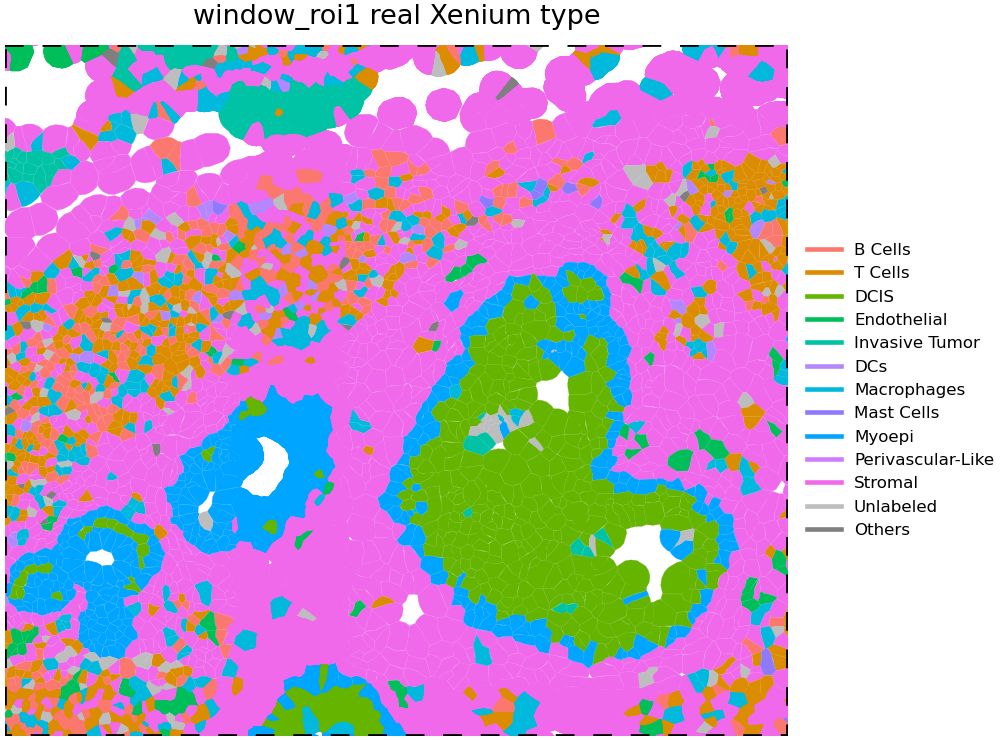
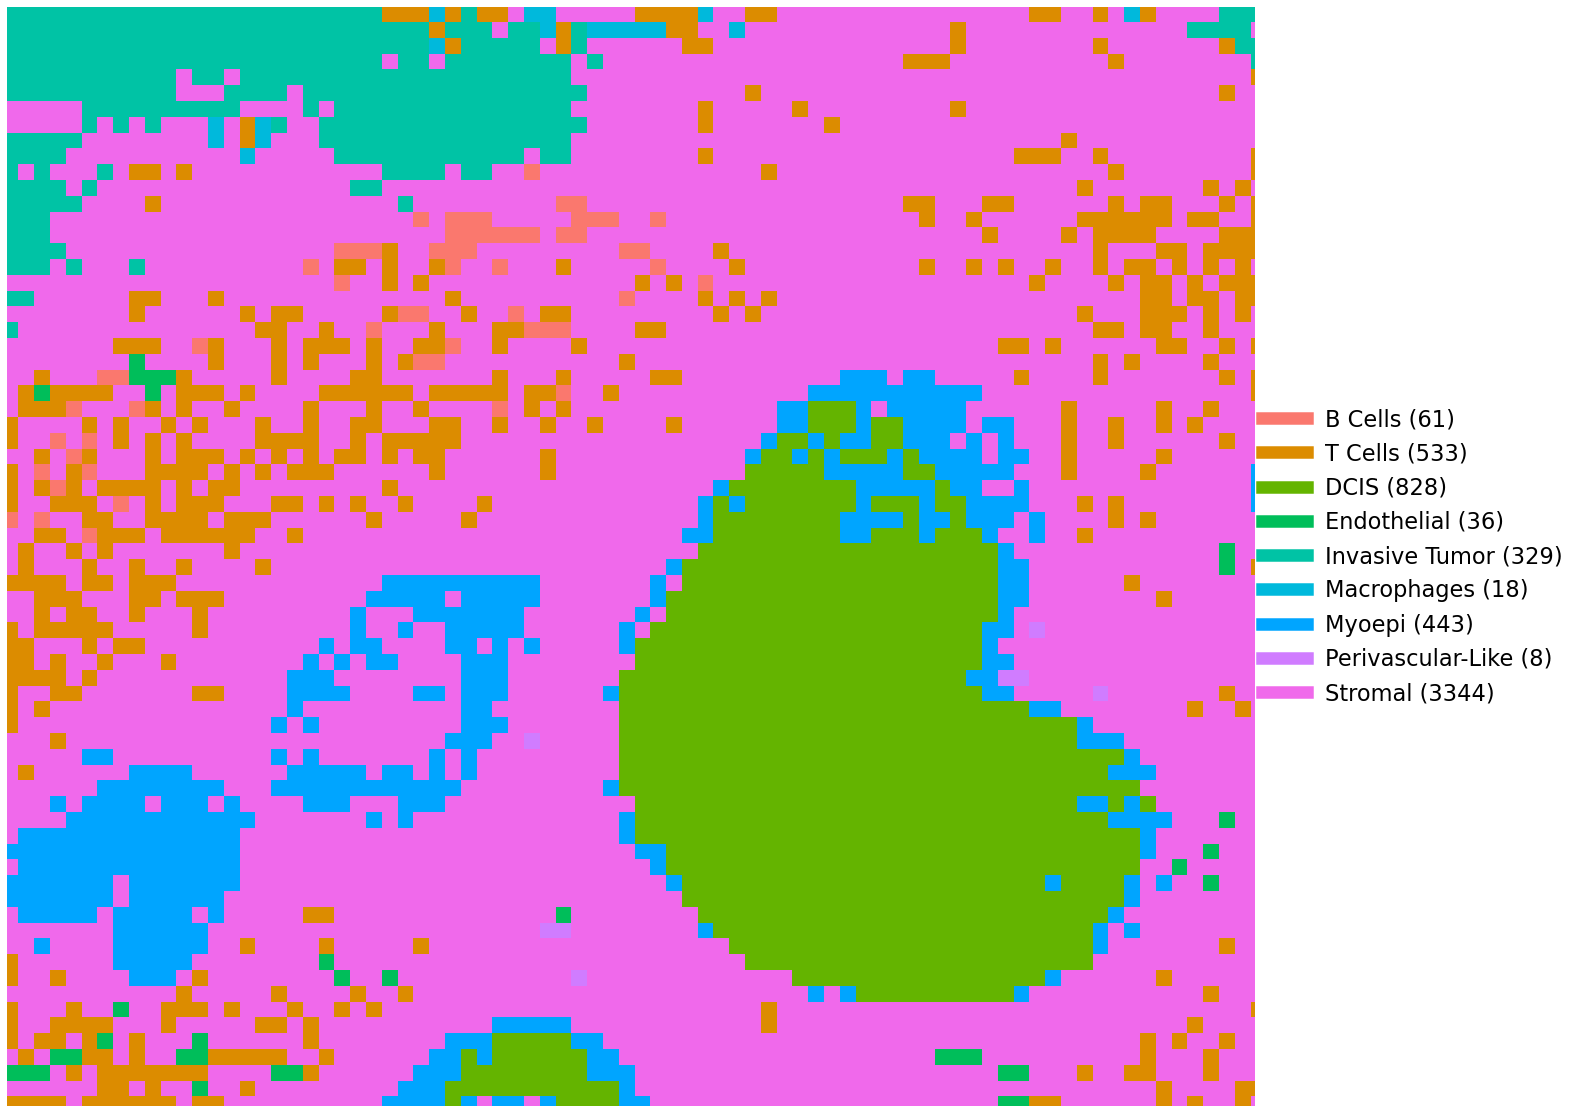

In [13]:
type_plot = spacerec.plottype(
    dataset=dataset,
    grid_type_csv=grid_type_csv,
    true_xen_type_csv=true_xen_type_csv,
    type_merge_json=type_merge_json,
    window=type_evaluation_window,
    window_label=type_window_label,
    output_dir=evaluation_dir,
)
display_image_pair(type_plot["true_type_png"], type_plot["grid_type_png"])


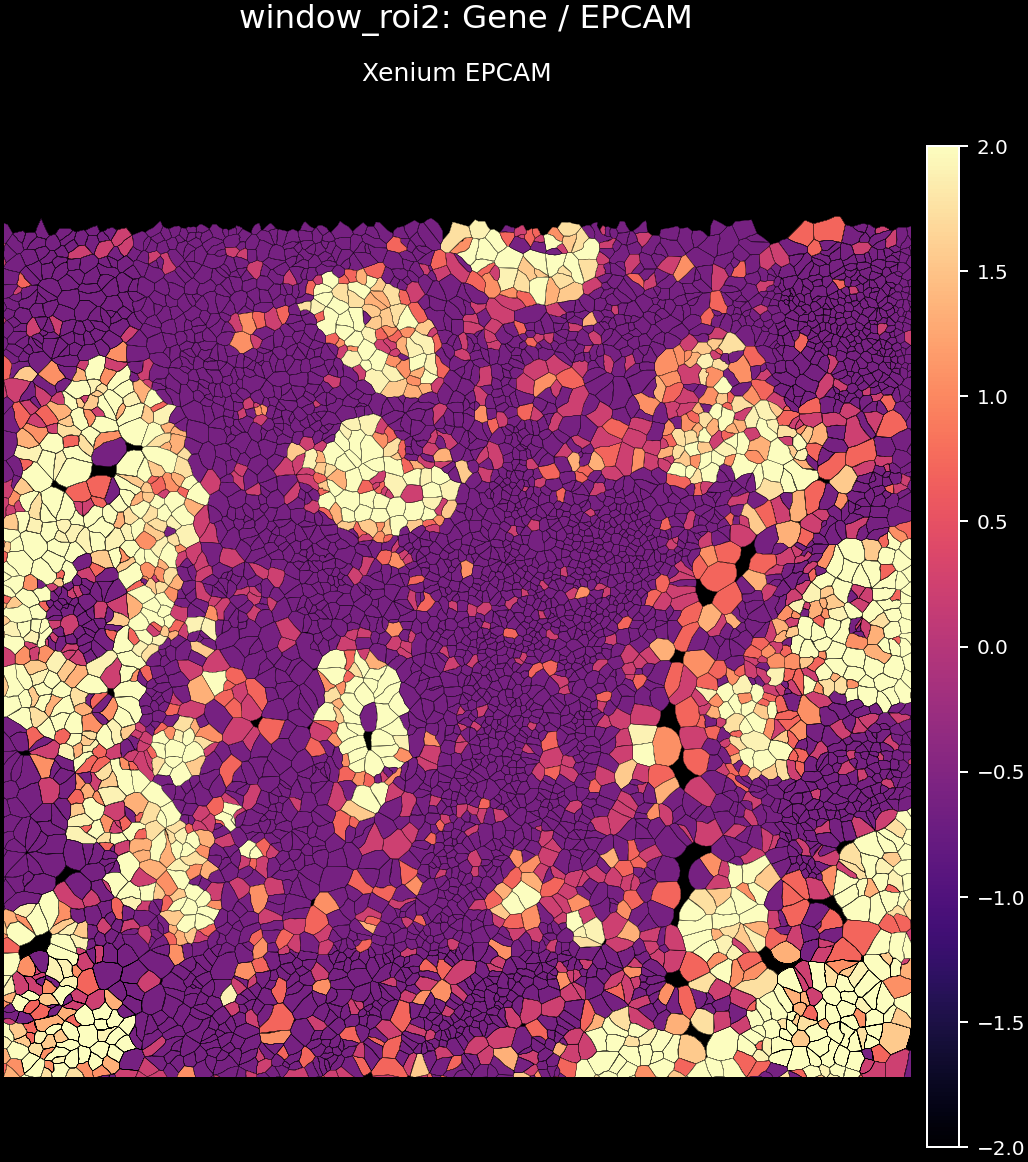
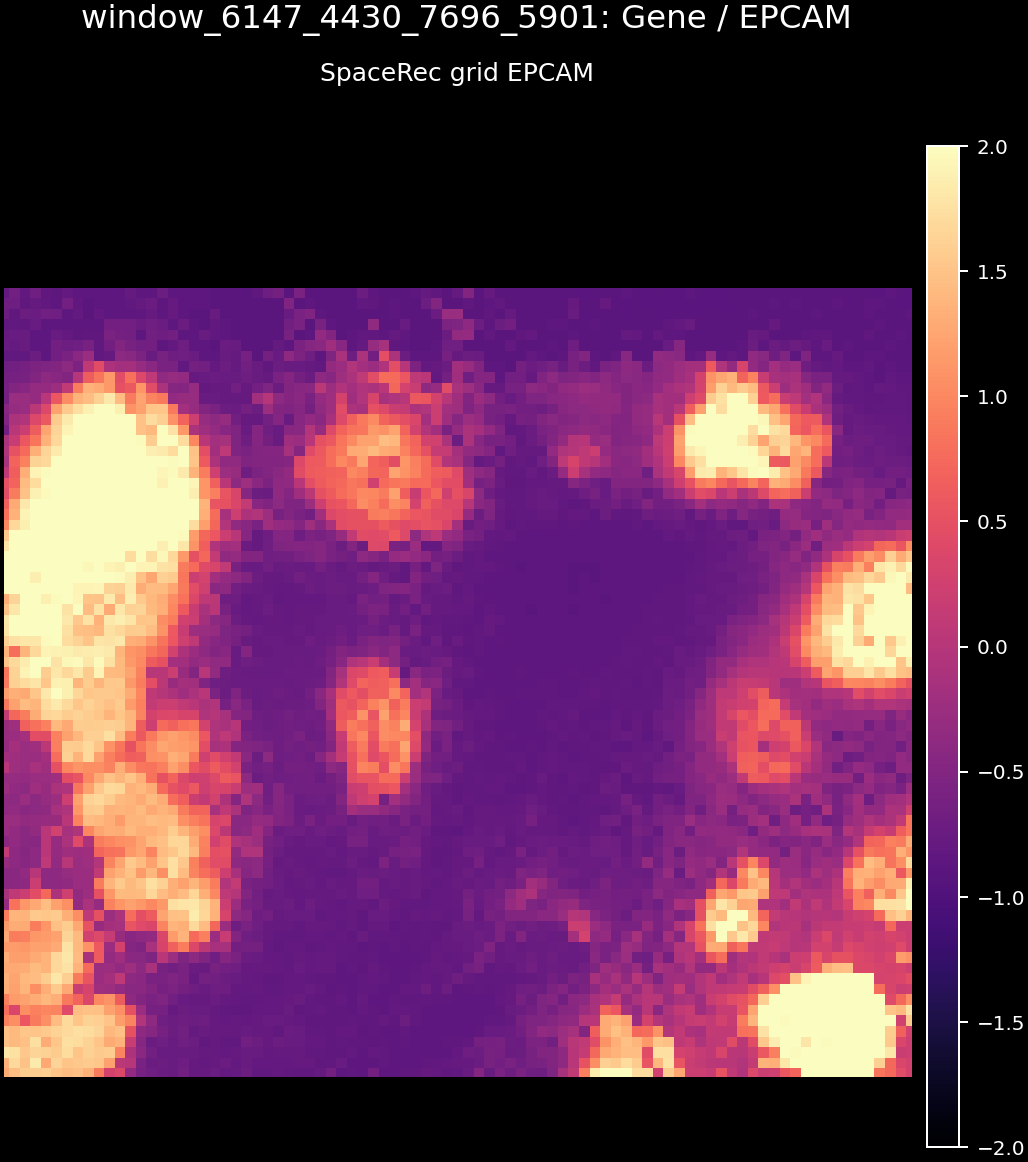

In [10]:
expr_plot = spacerec.plotexpr(
    dataset=dataset,
    grid_expr_h5ad=grid_expr_h5ad,
    true_xen_expr_h5=true_xen_expr_h5,
    true_xen_type_csv=true_xen_type_csv,
    polygon_window_label=expr_polygon_window_label,
    window=expr_evaluation_window,
    output_dir=evaluation_dir,
    gene=evaluation_gene,
)
display_image_pair(expr_plot["xen_expr_png"], expr_plot["grid_expr_png"])